# **Studying GraphRAG and LightRAG**

## Published from Microsoft in 2024 

このノートブックでは、2024年にMicrosoft社が出した”From Local to Global: A GraphRAG Approach to Query-Focused Summarization”について勉強する。

論文のURL:https://arxiv.org/abs/2404.16130

Github Repository:https://github.com/microsoft/graphrag.git

まず、論文を読みまとめを行う

↑　上記に加えて、それを発展させたLightRAGについての研究論文（LightRAG: Simple and Fast Retrieval-Augmented Generation）も査読し、こちらついてもまとめる。また、実験の再現を試みる。

論文のURL:https://arxiv.org/abs/2410.05779

Github Repository:https://github.com/HKUDS/LightRAG.git

本来はGraphRAG自体の実装を試みていたが、調べたところによるとGraphRAGはOpenAI API使用が基本的に推奨されており、ローカルLLMを用いて実験再現を行うためのパイプラインが揃っていなかった。（加えて、論文を読み込むと非常に時間とコストが多くかかってしまう。）

そこで、行き当たりばったりな決断ではあるが、そのGraphRAGを発展させたLightRAGについても一遍に学習し、こちらの再現を試みると決断した。

## はじめに

### GraphRAG

　GraphRAG論文を読んだうえでの要約、気になったことをまとめる。

　Abstructでは、この論文におけるGraphRAGが従来のVectorRAG(あるいはChunk-Based-RAG)が苦手としていた、 queryfocused summarization (QFS) task（raw-text全体を要約するようなタスク）に対して正確に回答する為に提案されたことが書かれている。

　Introductionについて。そもそもRAGとは、LLMのコンテクスト長を明らかに超えるトークン量のRAGテキストのQueryを一度に処理する為の技術である。ところが、従来のRAGというのは”What are the key trends in how scientific discoveries are influenced by interdisciplinary research over the past decade?”といった形のSencemaking queryには向かない。それは、Vectorのコサイン類似度から最も近かったチャンクを上から幾つか取ってくる形のシステムであるため。そこでGraphRAGの提案がなされる。その名の通り、graphによる論理構造を用いたRAGである。実験ではGPT-4をモデルとして使用した際にGraphRAGはVectorRAGよりも良い結果を残している。

　Backgroundでは、従来のRAGやKnowledge Graphを用いたRAGとの差分に触れつつ、本研究の評価上の課題についてまとめられている。GraphRAGにおけるqueryがsencemaking-query、つまり従来のVectorRAG以上に絶対的な正解を持てない取り組みであるからこそ、既存のRAGASのような評価方法、あるいは HotPotQA、MultiHop-RAG、MT-Bench のようなベンチマークではその精度を測定することが困難である。そのため研究では、LLMを用いてコーパス固有の高次質問を生成するadaptive benchmarkingを導入し、さらにLLM-as-a-judgeによって回答を比較評価する。評価基準としては、回答がどれだけ詳細に問いをカバーするかを測るComprehensiveness、異なる観点や洞察の豊かさを測るDiversity、読者の理解や判断をどれだけ助けるかを測るEmpowermentが設計されている。

　Methodは以下のFigure1を基にまとめる。

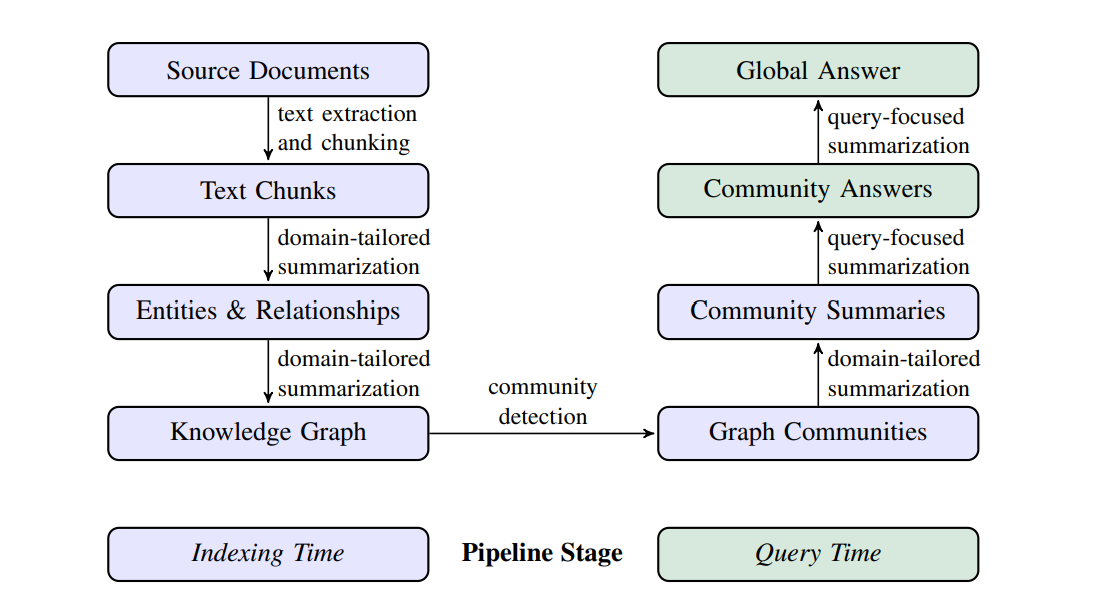

　まずSourceDocument(raw-text)を幾つかのTextChunkとしてそれぞれ区分けする。それをLLMを直接用いることで、TextChunkからEntitiesとRelationshipsを分類させる。次に統合して知識グラフを構築し、Leiden Algorithmによって巨大なグラフを階層的なコミュニティへと分割する。各コミュニティについてLLMが要約を生成する。質問応答時には関連するコミュニティ要約から部分回答を作成し、それらを統合して最終的な回答を生成する。

　ここでLeiden Algorithmとは、知識グラフ内のノード間の関係の強さに基づいて、密接に関連するノード群を階層的なコミュニティとして検出・分割するためのアルゴリズムである。

Leiden法参考元URL：https://qiita.com/engchina/items/643c9185495503211e19#3-%E3%82%B0%E3%83%AB%E3%83%BC%E3%83%97%E5%88%86%E3%81%91%E3%81%AE%E7%B5%90%E6%9E%9C%E5%88%86%E6%9E%90

↑思ったよりもネット上だと資料が少なかったです。。

　また下記のアルゴリズムは今回のテストQueryを生成する為のものである。合計でK=M=N=5として、その3乗の125個のqueryを出す。

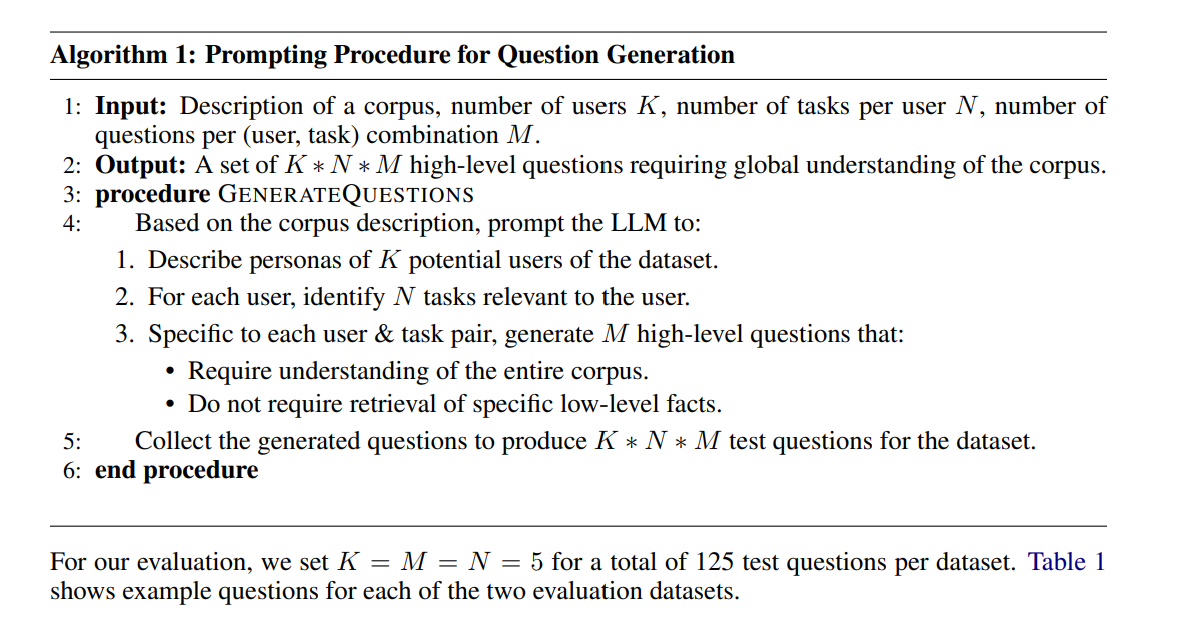

　Analysisでは、実験の詳細についてまとめられている。それぞれExperiment1とExperiment2として分けられている。

　Experiment1について。one million（100万） token rangeで切った2つのデータセットを用いる。1つはPodcast transcript(音声番組を文字起こししたもの。)もう1つは、News articles(ニュースの記事)。4.1.2 Conditionでは、C0~C3, TS, SSという場合に分けた検証を行ったことについて書いている。C0は最も粗いCommunity要約をLLMに渡す。C1は high-level community summaries（上位の階層の要約）を渡す。C2は中間レベルを、C3は最下層の要約を渡す。TSは、グラフを使わず、文章チャンクを直接map-reduce要約としてLLMに渡す。SSは、通常のVectorRAGである。Configurationによると、実行環境は『virtual machine
(16GB RAM, Intel(R) Xeon(R) Platinum 8171M CPU @ 2.60GHz) and using a public OpenAI
endpoint for gpt-4-turbo (2M TPM, 10k RPM)』。600 token windowにおけるPodcastのGraphIndexingには、 281分の実行時間を要した。（ここで600 token windowとか元文章を600token単位で切断したってこと。）

　Experiment2について。LLM-as-a-judgeによる評価結果を、claim数とclaimクラスタ数という別指標で検証するための補助実験である。

　その実験の結果として、GraphRAGが従来のSemantic Search型RAGよりも、global sensemakingにおいて有効であることが示されている。コーパス全体を踏まえた質問に対しては、局所的なチャンク検索だraphRAGが従来のSemantic Search型RAGよりも、global sensemakingにおいて有効であることが示されている。コーパス全体を踏まえた質問に対しては、局所的なチャンク検索だけでは不十分であることが分かる。一方で、C0〜C3のどの階層が最も有効かはデータセットによって異なり、News ArticlesではC0、Podcast TranscriptsではC2が良い結果を示している。このことから、コミュニティ要約の粒度には、情報の詳細さと処理コストの間にトレードオフがあると考えられる。また、C0は使用トークン数が非常に少ないにもかかわらずSSを上回っており、GraphRAGは性能面だけでなく、繰り返し質問に対する効率性の面でも利点を持つと読める。


　この論文を読んだ上での所感として、GraphRAGはまだ完璧な発明品ではないと思った。（不遜極まりない意見ではあると思うが。）まず、インデックス構築にかかった時間281分というのは実用性を考えた時にあまりに長すぎるだろう。加えて、その間も繰り返しLLMを呼び出しているため、API経由であれば多額の料金が必要になる。また、一度グラフが完成した後に追加テキストを入れなくてはいけなくなった場合の処理についてもここでは触れられていない。飽くまでもGraphRAGにおけるKnowledge-Graphは静的なものとして扱われている。最後に、Indexing事態にLLMを使っているため、潜在的にパースエラーやハルシネーションのリスクが非常に高い。現在のChatGPTやGeminiといったサービスにおいてはVectorRAGが用いられているという話は聞くが、その理由がこれを読んだことではっきりとわかった。GraphRAGは確かにsensemakingにおいて有効であることは確かだが、その利点を補って余りある課題が存在している。

### LightRAG

　LightRAG論文を読んだ上で要約を行う。

## 実装

　GraphRAGコードの実行自体は、 https://microsoft.github.io/graphrag/get_started/ に書かれている手順を踏むことで可能であったが、実行には多量の時間の大量のAPI消費が必要とあった。そこで、LightRAGの実装を試みる。実装にあたっては前に用いていたHuggingface PipelinesではなくOllamaを用いる。（使ったことは実の所無いが、突貫で進める。）Ollama経由でローカルLLMを入れ、uv add lightrag-hkuをインストールしたうえで、ローカル上で実行する。

## 関心・疑問になったこと

## 今後の研究計画について

今回やったGraphRAGが、私が想像していた以上に計算資源を使ってしまうことが明らかになった


そこで、今度はLightRAGについて

## あとがき・感想